## Week 18

## Unsupervised learning


Unsupervised Learning is a type of Machine Learning where:  

The data has no labels (no correct answers)   
The model learns by finding patterns on its own  

“Unsupervised learning means learning from data without being told the correct output.”

##### Unsupervised learning म्हणजे unlabeled data मधून model स्वतःच patterns learn करतो.

### 1️⃣ Clustering

Group similar data points together

👉 Same cluster = high similarity  
👉 Different clusters = low similarity

Similar data group करणे

- #### Popular Algorithms:

K-Means  
Hierarchical Clustering  
DBSCAN  

#### Example: Customer segmentation



समजा:

Students चा data आहे (marks, height, etc.)  
पण कोण “good” किंवा “average” आहे ते दिलेलं नाही

👉 Model काय करेल?

Similar students एकत्र group करेल

✔ High marks → एक group  
✔ Low marks → दुसरा group

👉 याला म्हणतात Clustering

- #### K-means

K-Means मध्ये:

Data ला K groups (clusters) मध्ये divide करतो  
Similar data points → same cluster

Cluster Labels: [1 1 1 0 0 0]
Centroids:
 [[ 42.33333333 160.        ]
 [ 87.66666667 172.33333333]]


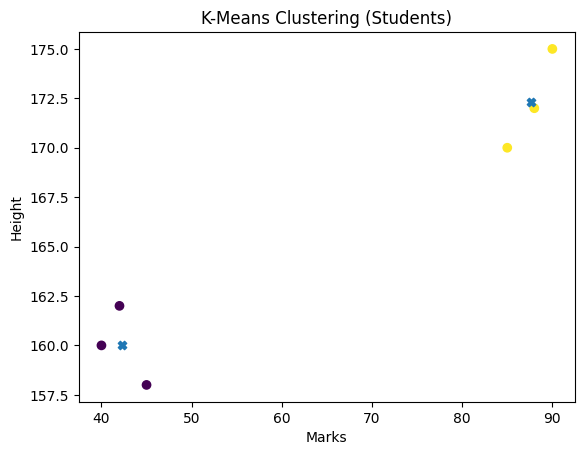

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Students data [marks, height]
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Step 2: Create model (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=0)

# Step 3: Train model
kmeans.fit(X)

# Step 4: Output
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster Labels:", labels)
print("Centroids:\n", centroids)

# Step 5: Visualization
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X')
plt.xlabel("Marks")
plt.ylabel("Height")
plt.title("K-Means Clustering (Students)")
plt.show()

- #### Heirarchical Clusturing

Hierarchical clustering मध्ये:

सुरुवातीला प्रत्येक point = separate cluster  
नंतर nearest clusters merge करतो

👉 शेवटी tree structure (Dendrogram) तयार होतो

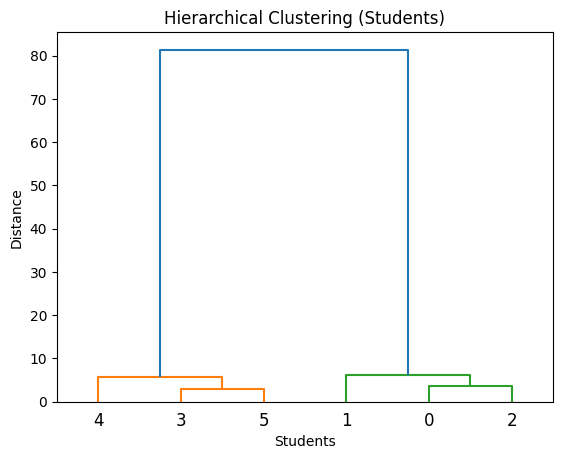

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Students data [marks, height]
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Step 1: Apply linkage
Z = linkage(X, method='ward')

# Step 2: Plot dendrogram
dendrogram(Z)
plt.title("Hierarchical Clustering (Students)")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

- #### DBSCAN

DBSCAN हा एक clustering algorithm आहे जो:

density (घनता) वर आधारित clusters तयार करतो  
आणि outliers (noise) पण detect करतो

जिथे points जास्त जवळ आहेत → cluster, दूर असलेले → noise

Cluster Labels: [0 0 0 1 1 1]


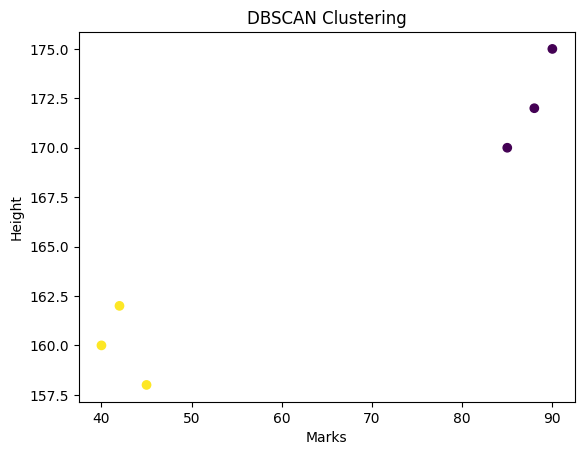

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Students data
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Model
db = DBSCAN(eps=5, min_samples=2)

# Train
labels = db.fit_predict(X)

print("Cluster Labels:", labels)

# Visualization
plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("Marks")
plt.ylabel("Height")
plt.title("DBSCAN Clustering")
plt.show()

### 2️⃣ Association

“If this happens → then that also happens”

👉 Items मधील relation शोधणे  

- #### Algorithm:

Apriori Algorithm

#### Example: 
Market basket



Shopping Example

Supermarket मध्ये:

Customers काय घेतात त्याचा data आहे

👉 Model find करतो:

“Chips घेतले तर cold drink पण घेतात”

👉 याला म्हणतात Association

- #### Apriori Algorithm

Apriori Algorithm हा एक algorithm आहे जो:

frequent itemsets (वारंवार येणारे items) शोधतो  
आणि त्यातून association rules तयार करतो

Data मधून वारंवार येणारे items शोधून त्यांच्यातील संबंध (rules) काढतो

In [12]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Transaction Data (Supermarket)
data = {
    'Chips':        [1, 1, 0, 1, 0],
    'Cold Drink':   [1, 1, 1, 0, 0],
    'Biscuits':     [0, 1, 1, 1, 0],
    'Chocolate':    [1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Dataset:\n", df)

# Step 2: Find Frequent Itemsets
freq_items = apriori(df, min_support=0.4, use_colnames=True)

print("\nFrequent Itemsets:\n", freq_items)

# Step 3: Generate Association Rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)

print("\nAssociation Rules:\n", rules)

Dataset:
    Chips  Cold Drink  Biscuits  Chocolate
0      1           1         0          1
1      1           1         1          0
2      0           1         1          1
3      1           0         1          1
4      0           0         0          1

Frequent Itemsets:
    support                 itemsets
0      0.6                  (Chips)
1      0.6             (Cold Drink)
2      0.6               (Biscuits)
3      0.8              (Chocolate)
4      0.4      (Cold Drink, Chips)
5      0.4        (Biscuits, Chips)
6      0.4       (Chocolate, Chips)
7      0.4   (Biscuits, Cold Drink)
8      0.4  (Chocolate, Cold Drink)
9      0.4    (Chocolate, Biscuits)

Association Rules:
     antecedents   consequents  antecedent support  consequent support  \
0  (Cold Drink)       (Chips)                 0.6                 0.6   
1       (Chips)  (Cold Drink)                 0.6                 0.6   
2    (Biscuits)       (Chips)                 0.6                 0.6   
3       

C:\Users\jadha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


### 3️⃣ Dimensionality Reduction

👉 Features कमी करणे

- #### Algorithms:

PCA (Principal Component Analysis)  
t-SNE

#### Example:    
- Big data simplify करणे  
- Image compression  
- Data visualization

## K-Means algorithm


K-Means is a popular unsupervised machine learning algorithm used to group unlabeled data into "K" distinct, non-overlapping clusters based on similarity

K-Means groups data into K clusters based on similarity.

👉 “K” = number of clusters you want  
👉 “Means” = average (centroid of each cluster)

K-Means cha main goal aahe:

👉 “Similar data points ekatra group karne”  
👉 “Sarkhya values aslele data ekach group madhe takne”


### Working of K-Means (Step-by-Step)

1. Choose K (number of clusters)  
2. Initialize centroids randomly  
3. Assign data points to nearest centroid (using distance like Euclidean distance)  
4. Update centroids → Calculate new mean of each cluster  
5. Repeat steps 3 & 4 until no change  

#### Real Life Example:

Samja tujhya class madhe students aahet:

Kahi students → high marks  
Kahi → average  
Kahi → low  

👉 Teacher manually group karto  
👉 Pan K-Means automatically grouping karto

#### Formula

Distance find karayla (Euclidean distance):

    d= (x1−x2)2 + (y1−y2)2

#### Why K-Means works?

👉 Because:

Similar points → near astat  
Dissimilar → far astat

👉 So grouping easy hote

### Example 1

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()

X = iris.data   # features

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
print("Cluster Labels:\n", kmeans.labels_)
print("Centroids:\n", kmeans.cluster_centers_)

Cluster Labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
Centroids:
 [[5.88360656 2.74098361 4.38852459 1.43442623]
 [5.006      3.428      1.462      0.246     ]
 [6.85384615 3.07692308 5.71538462 2.05384615]]


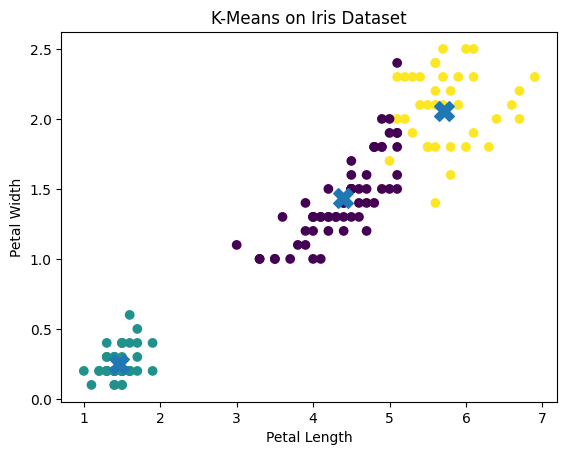

In [ ]:
plt.scatter(X[:, 2], X[:, 3], c=kmeans.labels_)

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 2],
            kmeans.cluster_centers_[:, 3],
            marker='X', s=200)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means on Iris Dataset")

plt.show()

### Example 2

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
marks = [35, 40, 45, 50, 55, 60, 65, 70, 85, 90, 95]

In [ ]:
X = np.array(marks).reshape(-1, 1)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)

In [ ]:
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
print("Marks:", marks)
print("Cluster Labels:", kmeans.labels_)
print("Centroids:", kmeans.cluster_centers_)

Marks: [35, 40, 45, 50, 55, 60, 65, 70, 85, 90, 95]
Cluster Labels: [2 2 2 2 0 0 0 0 1 1 1]
Centroids: [[62.5]
 [90. ]
 [42.5]]


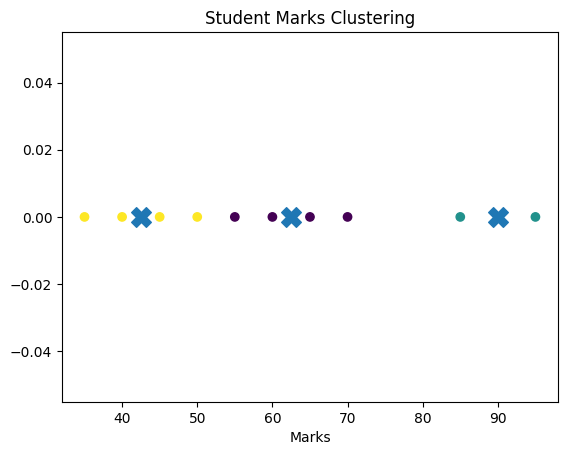

In [ ]:
plt.scatter(X, [0]*len(X), c=kmeans.labels_)

plt.scatter(kmeans.cluster_centers_,
            [0]*len(kmeans.cluster_centers_),
            marker='X', s=200)

plt.title("Student Marks Clustering")
plt.xlabel("Marks")

plt.show()

- #### PCA:

What is PCA?

👉 PCA हा एक technique आहे जो:

Data मधील features (columns) कमी करतो  
पण important information (variance) जपून ठेवतो

In [13]:
from sklearn.decomposition import PCA
import numpy as np

# Data
X = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

# PCA
pca = PCA(n_components=2)
X_new = pca.fit_transform(X)

print("Reduced Data:\n", X_new)

Reduced Data:
 [[-5.19615242e+00 -2.56395025e-16]
 [ 0.00000000e+00 -0.00000000e+00]
 [ 5.19615242e+00 -2.56395025e-16]]


- #### t-SNE:

What is t-SNE?

👉 t-SNE हा technique आहे जो:

High-dimensional data → 2D/3D मध्ये convert करतो  
Visualization साठी best आहे

t-SNE Output:
 [[1080.7062      0.      ]
 [ -19.816063    0.      ]
 [ 307.85825     0.      ]
 [ 752.80035     0.      ]]


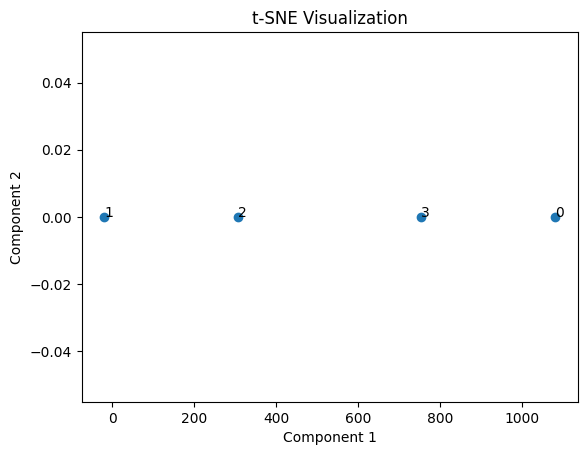

In [16]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([[1,2,3],
              [4,5,6],
              [7,8,9],
              [2,3,4]])

# t-SNE (fixed perplexity)
tsne = TSNE(n_components=2, perplexity=2, random_state=0)

X_new = tsne.fit_transform(X)

print("t-SNE Output:\n", X_new)

# 📊 Plot Graph
plt.scatter(X_new[:,0], X_new[:,1])

# Label each point
for i, txt in enumerate(range(len(X_new))):
    plt.annotate(txt, (X_new[i,0], X_new[i,1]))

plt.title("t-SNE Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## K-mediod

K-Medoids is an unsupervised learning algorithm used for clustering (grouping similar data points together).  
It is very similar to K-Means Clustering, but with one key difference.

#### 🔹 Key Idea  
K-Means uses the average (mean) of points → called centroid  
K-Medoids uses an actual data point → called medoid

👉 A medoid is the most centrally located real point in a cluster.

.

K-Medoids हा एक unsupervised learning algorithm आहे जो data ला clusters मध्ये divide करतो.

👉 Similar to K-Means Clustering, पण एक important फरक आहे:

K-Means → centroid (mean value) वापरतो    
K-Medoids → actual data point (medoid) वापरतो

### What is a Medoid?

A medoid is:  
The data point in a cluster whose total distance to all other points in that cluster is minimum.

✔ It is always a real point from the dataset (not an average)

#### 🔹 How K-Medoids Works (Step-by-Step)

1️⃣ Select k random points as initial medoids  
2️⃣ Assign each data point to the nearest medoid  
3️⃣ Calculate total cost (sum of distances)  
4️⃣ Swap step:  

- Try replacing a medoid with a non-medoid point  
- If cost decreases → accept the swap  
5️⃣ Repeat until no improvement

### 🔹 Example

Dataset:

[10, 12, 15, 50, 55, 60]

Let k = 2

Clusters formed:

Cluster 1 → [10, 12, 15] → Medoid = 12  
Cluster 2 → [50, 55, 60] → Medoid = 55

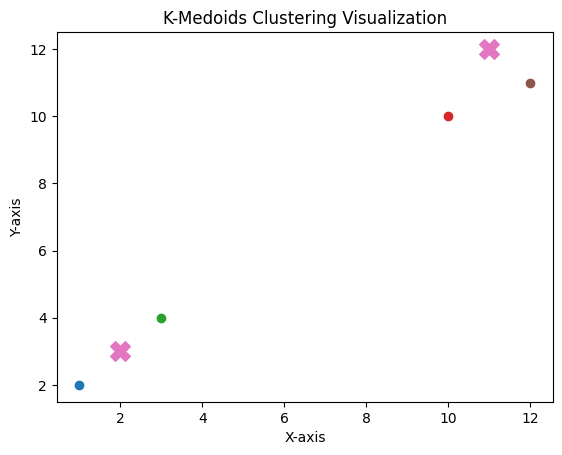

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids

# Sample 2D dataset
X = np.array([
    [1, 2], [2, 3], [3, 4],   # Cluster 1
    [10, 10], [11, 12], [12, 11]  # Cluster 2
])

# Apply K-Medoids
kmedoids = KMedoids(n_clusters=2, random_state=0)
kmedoids.fit(X)

labels = kmedoids.labels_
medoids = kmedoids.cluster_centers_

# Plot clusters
for i in range(len(X)):
    if labels[i] == 0:
        plt.scatter(X[i][0], X[i][1])
    else:
        plt.scatter(X[i][0], X[i][1])

# Plot medoids (bigger markers)
plt.scatter(medoids[:, 0], medoids[:, 1], marker='X', s=200)

plt.title("K-Medoids Clustering Visualization")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

.

## Heirarchical Clustering

Hierarchical Clustering is an unsupervised machine learning technique used to group similar data points into clusters.  
It forms a tree-like structure called a dendrogram, which shows how clusters are created step by step.  
👉 Hierarchical clustering groups data step-by-step based on similarity, forming a tree of clusters.

marathi: 
Ji data points la similarity varun groups (clusters) madhe divide karte  
He clustering ek tree structure madhe represent hote, jyala Dendrogram mhanatat

👉 “Similarity (sarkhya goshti) varun data la step-by-step group karne = Hierarchical Clustering”

#### 🔹 Example : Shopping Data

Samja tumchya kade customers cha data aahe:

Customer A → ₹1000 shopping  
Customer B → ₹1100  
Customer C → ₹5000  
Customer D → ₹5200

👉 Algorithm kasa vichar karto:

A ani B → close aahet (1000 vs 1100)  
C ani D → close aahet (5000 vs 5200)

👉 So clusters:

Cluster 1 → (A, B)  
Cluster 2 → (C, D)

👉 Final grouping:

Low spenders  
High spenders

#### 🔹 Example 2 : Students

Marks:

A → 40  
B → 42  
C → 85  
D → 90  

👉 Clustering:

(A, B) → low marks  
(C, D) → high marks

👉 Final:

Cluster 1 → weak students  
Cluster 2 → topper students

#### 🔹 Dendrogram
A tree diagram that shows how clusters are merged or split  
You can decide the number of clusters by cutting the tree at a certain level

- marathi :  

Dendrogram = tree diagram 🌳

Bottom → individual points  
Top → final cluster  
Height → distance between clusters

👉 Tumhi kuthe cut karta tyavar clusters decide hotat

Example:

Low height la cut → jast clusters
High height la cut → kami clusters

#### 🔹How it works (Basic Idea)
Data points that are similar are grouped together  
Data points that are different are placed in different clusters  
Clustering happens gradually (step-by-step), not all at once

### 🔹 How distance is calculated between clusters?

When we merge clusters, we need to decide:  
👉 “Which clusters are closest?”

Different methods calculate this distance in different ways.

#### 1️⃣ Single Linkage (Nearest Neighbor)

It checks the closest pair of points between two cluster   
👉 “Minimum distance” between clusters

🔸 Example:

Cluster A = (2, 3)  
Cluster B = (10, 12), (3, 4)

👉 Closest points:  
(2,3) and (3,4) → distance is small

👉 So clusters will merge

#### 2️⃣ Complete Linkage (Farthest Neighbor)

It checks the farthest points between clusters  
👉 “Maximum distance” between clusters

🔸 Example:

Cluster A = (2, 3)  
Cluster B = (10, 12), (3, 4)

👉 Farthest points:

(2,3) and (10,12) → large distance  
👉 So merging happens only if clusters are overall close

#### 3️⃣ Average Linkage

It calculates the average distance of all points between two clusters    
👉 “Take all distances and find average”

🔸 Example:

Cluster A = (2,3), (4,5)  
Cluster B = (10,12), (3,4)

👉 Distances:

(2,3) ↔ (10,12)  
(2,3) ↔ (3,4)  
(4,5) ↔ (10,12)  
(4,5) ↔ (3,4)  

👉 Take average of all → decide merging

#### 4️⃣ Ward’s Method (Most Important)

It merges clusters such that variance increases minimum  
👉 “Keep clusters as similar (compact) as possible”

🔸 What it does:

It tries to minimize difference inside cluster  
Avoids large spread clusters


### Types :

#### 1️⃣ Agglomerative Clustering (Bottom-Up)

👉 This is the most commonly used type

Suruvatila pratek data point = 1 cluster asto  
Nantar closest clusters merge hot jat   
Step-by-step ek big cluster tayar hoto

🔸 Simple Steps:

Start with all points as separate clusters  
Find the two closest clusters  
Merge them  
Repeat until only one cluster remains  

🔸 Example:

Marks:

A = 40  
B = 42  
C = 85  
D = 90 

👉 Process:

(A, B) merge → because they are close  
(C, D) merge → because they are close  
Final → (A, B, C, D) 

👉 Groups formed:

Low marks group  
High marks group

#### 2️⃣ Divisive Clustering (Top-Down)

👉 This is the opposite of agglomerative clustering

Suruvatila sagla data ekach cluster madhe asto    
Nantar step-by-step split karto    
Shevati small-small clusters banto

🔸 Simple Steps:

Start with all data in one cluster  
Divide it into two clusters  
Split again if needed  
Repeat until the required number of clusters is obtained

🔸 Example:

Same data:

A = 40  
B = 42  
C = 85  
D = 90  

👉 Process:

(A, B, C, D) → split  
(A, B) and (C, D)  
Further splitting if required  

| Feature          | Agglomerative Clustering              | Divisive Clustering                 |
| ---------------- | ------------------------------------- | ----------------------------------- |
| Approach         | Bottom-Up                             | Top-Down                            |
| Start Point      | Each data point is a separate cluster | All data points are in one cluster  |
| Process          | Clusters are **merged** step by step  | Clusters are **split** step by step |
| Direction        | Small → Big                           | Big → Small                         |
| Common Use       | Widely used in practice               | Rarely used                         |
| Complexity       | Less complex                          | More complex                        |
| Example Thinking | “Keep joining similar points”         | “Keep dividing dissimilar points”   |


#### 1️⃣ Agglomerative Clustering (Bottom-Up)

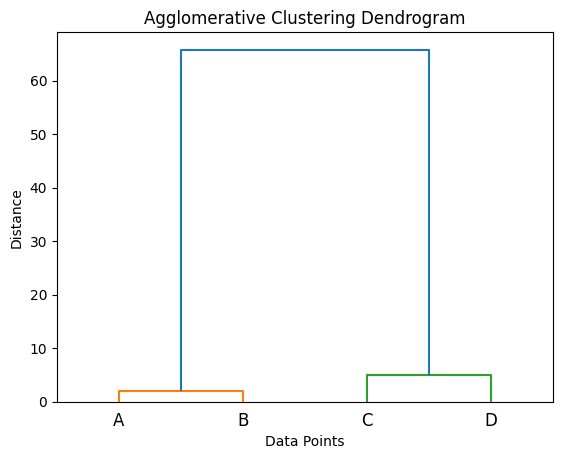

Cluster Labels: [1 1 0 0]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample data
data = np.array([[40], [42], [85], [90]])

# 🔸 Part 1: Dendrogram (Graph)
Z = linkage(data, method='ward')

plt.figure()
dendrogram(Z, labels=['A', 'B', 'C', 'D'])
plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# 🔸 Part 2: Model + Labels
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(data)

print("Cluster Labels:", labels)

#### 2️⃣ Divisive Clustering (Top-Down)


Step 1 Labels: [1 1 0 0]


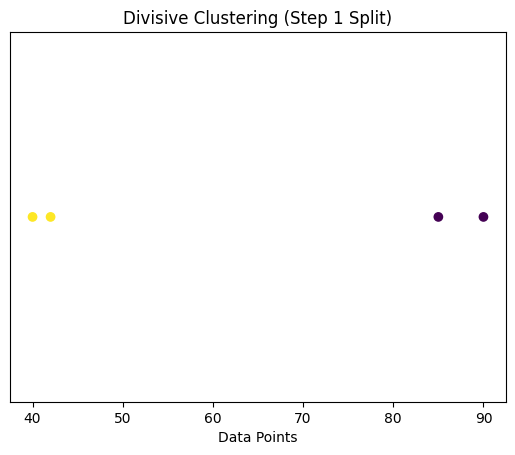

Further Split of Cluster 0: [1 0]


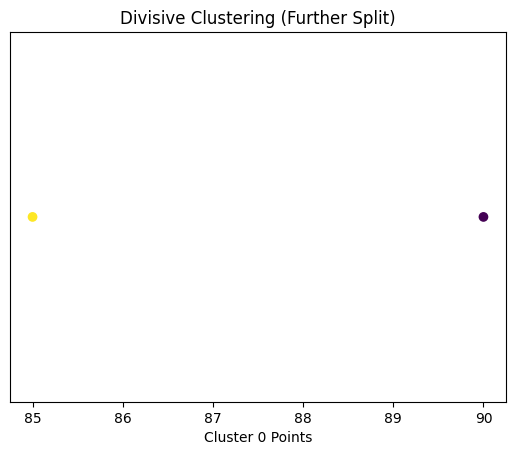

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample data
data = np.array([[40], [42], [85], [90]])

# 🔸 Step 1: Initial Split
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(data)

print("Step 1 Labels:", labels)

# 🔸 Graph (Scatter Plot)
plt.figure()
plt.scatter(data, [0]*len(data), c=labels)
plt.title("Divisive Clustering (Step 1 Split)")
plt.xlabel("Data Points")
plt.yticks([])
plt.show()

# 🔸 Step 2: Further split one cluster
cluster_0 = data[labels == 0]

if len(cluster_0) > 1:
    kmeans2 = KMeans(n_clusters=2, random_state=0)
    sub_labels = kmeans2.fit_predict(cluster_0)
    
    print("Further Split of Cluster 0:", sub_labels)

    # Graph for second split
    plt.figure()
    plt.scatter(cluster_0, [0]*len(cluster_0), c=sub_labels)
    plt.title("Divisive Clustering (Further Split)")
    plt.xlabel("Cluster 0 Points")
    plt.yticks([])
    plt.show()